In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

## **Carga de datos**

In [3]:
file_path = "online_shoppers_intention.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "henrysue/online-shoppers-intention",
  file_path
)

print('✅ Conjunto de datos cargado correctamente!')

✅ Conjunto de datos cargado correctamente!


In [4]:
print(f'El dataset está formado por {df.shape[0]} filas y {df.shape[1]} columnas')

El dataset está formado por 12330 filas y 18 columnas


In [5]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  str    
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType              12330 no

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,1.000000,4.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,7.500000,93.256250,3398.750000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,24.000000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,2549.375000
ProductRelated,12330.0,31.731468,44.475503,0.0,7.000000,18.000000,38.000000,705.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,184.137500,598.936905,1464.157214,63973.522230
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.003112,0.016813,0.200000
ExitRates,12330.0,0.043073,0.048597,0.0,0.014286,0.025156,0.050000,0.200000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,361.763742
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,1.000000


## **Preparación de datos**

### Tratamiento de Valores Nulos y Duplicados

In [8]:
# Detección de valores nulos
print('-> Valores nulos en el conjunto de datos <-')
print(df.isnull().sum())

-> Valores nulos en el conjunto de datos <-
Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


In [9]:
# Detección y eliminación de filas duplicadas
print(f'Se han encontrado y eliminado {df.duplicated().sum()} filas duplicadas')
df = df.drop_duplicates()

Se han encontrado y eliminado 125 filas duplicadas


In [10]:
print(f'Finalmente el conjunto de datos queda formado por {df.shape[0]} filas')

Finalmente el conjunto de datos queda formado por 12205 filas


### **Mapeo de Variables Categóricas**

A continuación, para añadir más realismo al problema, dado que ciertas variables categóricas han sido anonimizadas y se desconoce el valor real de esta, se ha decido usar los nombres con más sentido en base a la frecuencia de la clase en el conjunto de datos y a la frecuencia de estos en el año 2019, año de los datos recogidos en este dataset.

In [11]:
# --- 1. DICCIONARIO: SISTEMAS OPERATIVOS ---
os_mapping = {
    1: 'iOS (Mobile)', 
    2: 'Windows (Desktop)', 
    3: 'Android (Mobile)', 
    4: 'macOS (Desktop)', 
    5: 'ChromeOS', 
    6: 'Linux', 
    7: 'Other Mobile', 
    8: 'Other/Legacy'
}

# --- 2. DICCIONARIO: NAVEGADORES ---
browser_mapping = {
    1: 'Safari', 
    2: 'Chrome', 
    3: 'Safari Mobile', 
    4: 'Firefox', 
    5: 'Edge', 
    6: 'Samsung Internet', 
    7: 'Android Webview', 
    8: 'Opera', 
    10: 'UC Browser', 
    13: 'Otros/In-App'
}

# --- 3. DICCIONARIO: REGIONES ---
region_mapping = {
    1: 'Nacional (Sede)', 
    2: 'Europa Norte', 
    3: 'Europa Sur', 
    4: 'Norteamérica', 
    5: 'Latam', 
    6: 'Asia-Pacífico', 
    7: 'EMEA (Oriente Medio)', 
    8: 'África', 
    9: 'Oceanía'
}

# --- 4. DICCIONARIO: TIPO DE TRÁFICO (Canales de Marketing) ---
traffic_mapping = {
    1: 'SEO (Google)', 
    2: 'Directo', 
    3: 'SEM (Google Ads)', 
    4: 'Social Ads', 
    5: 'Afiliados', 
    6: 'Email Marketing', 
    7: 'Referidos Blog', 
    8: 'Display Banner', 
    10: 'Campañas SMS', 
    11: 'Retargeting', 
    13: 'Push Notifications',
    20: 'Otros Canales'
}

# --- APLICACIÓN DE LOS MAPEOS ---
df_eda = df.copy()

df_eda['OperatingSystems'] = df_eda['OperatingSystems'].map(browser_mapping)
df_eda['Browser'] = df_eda['Browser'].map(os_mapping)
df_eda['Region'] = df_eda['Region'].map(region_mapping)
df_eda['TrafficType'] = df_eda['TrafficType'].map(traffic_mapping)

In [12]:
df_eda[['OperatingSystems', 'Browser', 'Region', 'TrafficType']].head()

,OperatingSystems,Browser,Region,TrafficType
0,Safari,iOS (Mobile),Nacional (Sede),SEO (Google)
1,Chrome,Windows (Desktop),Nacional (Sede),Directo
2,Firefox,iOS (Mobile),Oceanía,SEM (Google Ads)
3,Safari Mobile,Windows (Desktop),Europa Norte,Social Ads
4,Safari Mobile,Android (Mobile),Nacional (Sede),Social Ads


## Análisis Exploratorio de Datos (EDA) - Univariante

### Distribución de la Variable Objetivo (Revenue)

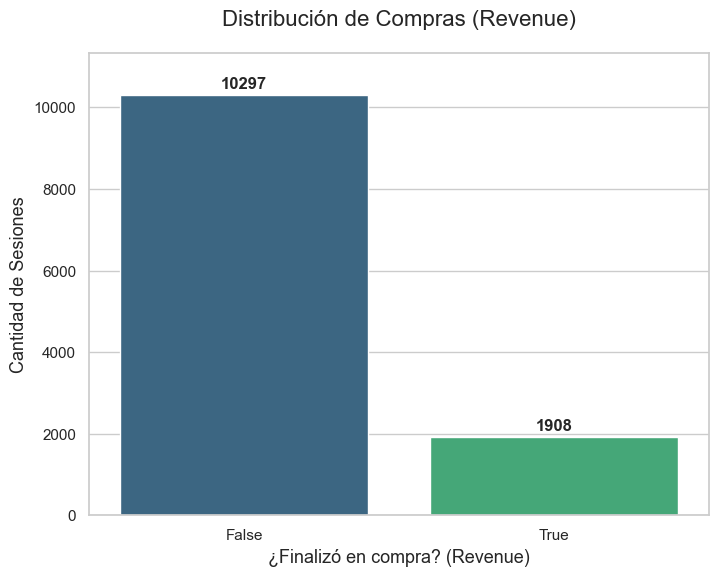

In [13]:
# Gráfico de la distribución de sesiones finalizadas en compras

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.countplot(x='Revenue', hue='Revenue', data=df_eda, legend=False, palette='viridis')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', padding=3)

plt.title('Distribución de Compras (Revenue)', fontsize=16, pad=20)
plt.xlabel('¿Finalizó en compra? (Revenue)', fontsize=13)
plt.ylabel('Cantidad de Sesiones', fontsize=13)

plt.ylim(0, df['Revenue'].value_counts().max() * 1.1)
plt.show()

### Análisis de Variables Numéricas

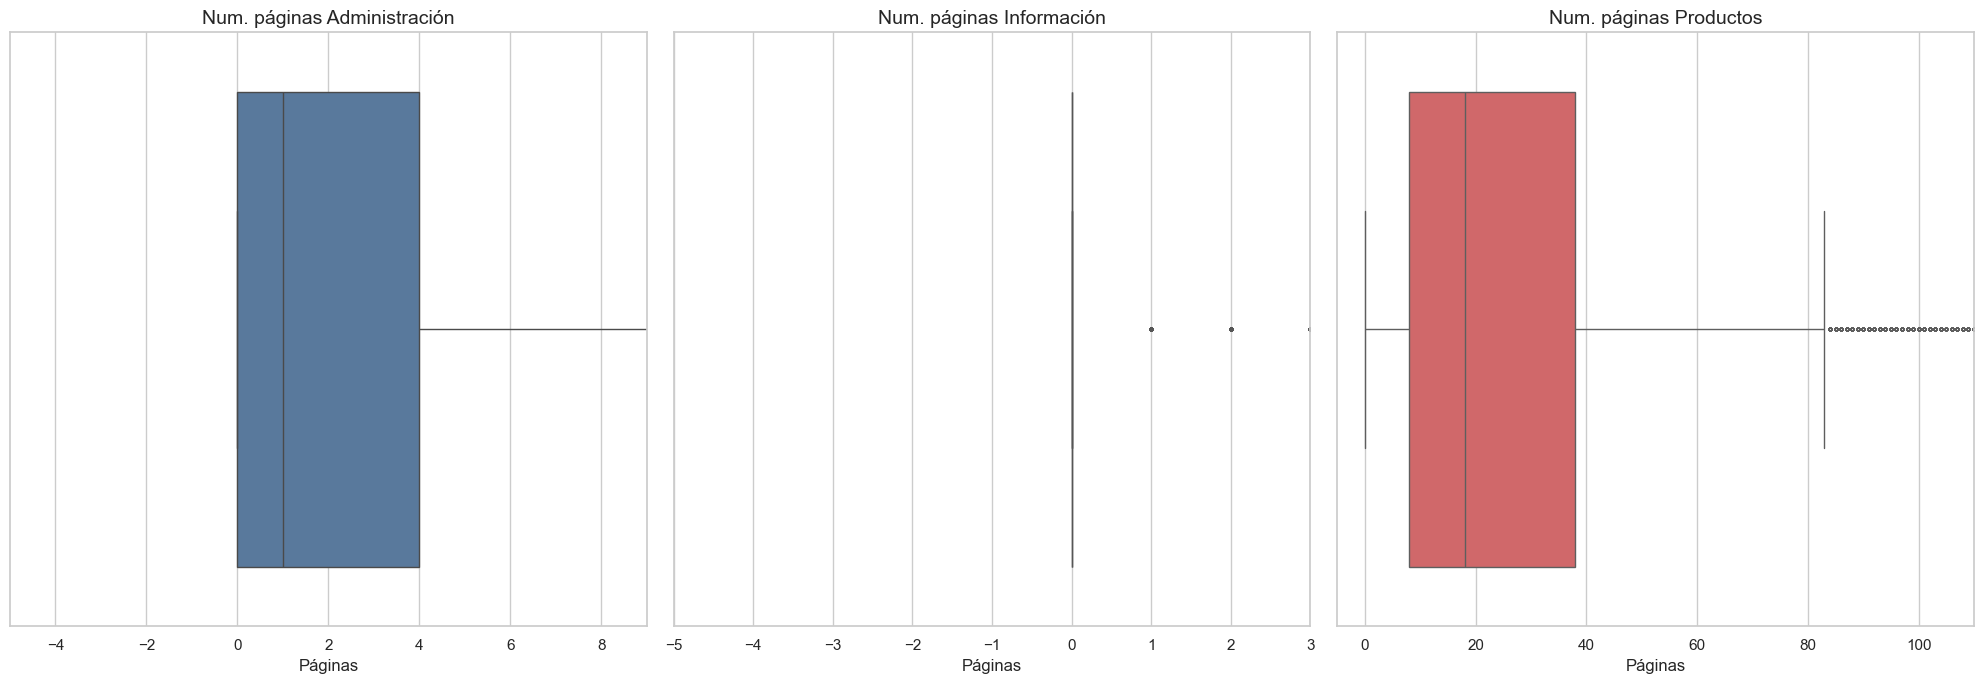

In [27]:
# Distribución de Num. Páginas

colores = ['#4e79a7', '#f28e2b', '#e15759']
variables = ['Administrative', 'Informational', 'ProductRelated']
titulos = ['Num. páginas Administración', 'Num. páginas Información', 'Num. páginas Productos']

plt.figure(figsize=(20, 7))

for i, var in enumerate(variables):
    plt.subplot(1, 3, i+1)
    
    limite_superior = df_eda[var].quantile(0.95)
    
    sns.boxplot(data=df_eda, x=var, color=colores[i], fliersize=2)
    
    plt.xlim(-5, limite_superior) 
    
    plt.title(titulos[i], fontsize=14)
    plt.xlabel('Páginas', fontsize=12)

plt.tight_layout()
plt.show()

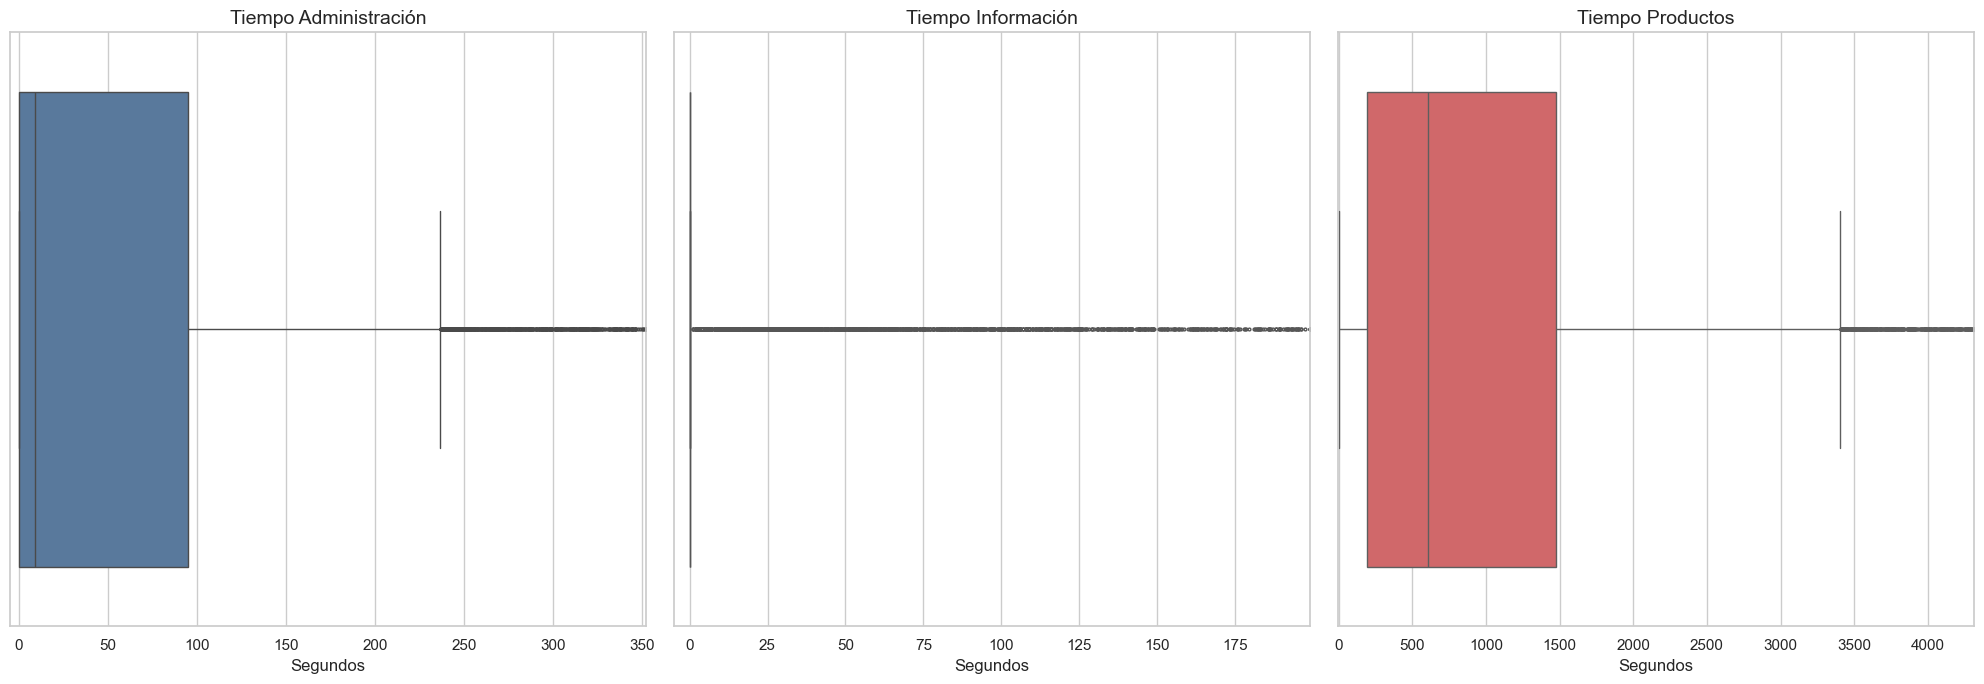

In [17]:
# Distribución de Tiempos

colores = ['#4e79a7', '#f28e2b', '#e15759']
variables = ['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration']
titulos = ['Tiempo Administración', 'Tiempo Información', 'Tiempo Productos']

plt.figure(figsize=(20, 7))

for i, var in enumerate(variables):
    plt.subplot(1, 3, i+1)
    
    limite_superior = df_eda[var].quantile(0.95)
    
    sns.boxplot(data=df_eda, x=var, color=colores[i], fliersize=2)
    
    plt.xlim(-5, limite_superior) 
    
    plt.title(titulos[i], fontsize=14)
    plt.xlabel('Segundos', fontsize=12)

plt.tight_layout()
plt.show()

### Análisis de Variables Categóricas

In [31]:
def plot_categorical_analysis(df, column, title_name, category_order = None):
    """
    Función encargada de, dada una columna categórica, generar una gráfica para mostrar el volumen de sesión en base a cada clase (diferenciado las acabadas en compra o no);
    y otra mostrando la tasa de compra por cada clase en base al volumen de estas.
    :param df: Conjunto de datos
    :param column: Columna categórica a analizar
    :param title_name: Nombre deseado para ser mostrado en los títulos
    :return: 
    """
    if category_order is None:
        category_order = df[column].value_counts().index.tolist()
    
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    sns.countplot(x=column, hue='Revenue', data=df, palette='viridis', ax=ax[0], order=category_order)
    ax[0].set_title(f'Volumen de Sesiones por {title_name}')
    ax[0].set_ylabel('Número de Sesiones')
    ax[0].tick_params(axis='x', rotation=45)

    prop_df = (df.groupby(column)['Revenue']
               .value_counts(normalize=True)
               .rename('percentage')
               .reset_index())
    prop_df['percentage'] *= 100

    sns.barplot(x=column, y='percentage', hue='Revenue', data=prop_df, palette='viridis', ax=ax[1], legend=False, order=category_order)
    ax[1].set_title(f'Tasa de Compra (%) por {title_name}')
    ax[1].set_ylabel('Porcentaje (%)')
    ax[1].tick_params(axis='x', rotation=45)

    for p in ax[1].patches:
        height = p.get_height()
        if height > 0: 
            ax[1].annotate(f'{height:.1f}%', 
                           (p.get_x() + p.get_width() / 2., height), 
                           ha='center', va='center', 
                           xytext=(0, 9), 
                           textcoords='offset points',
                           fontweight='bold',
                           fontsize=10)

    plt.tight_layout()
    plt.show()

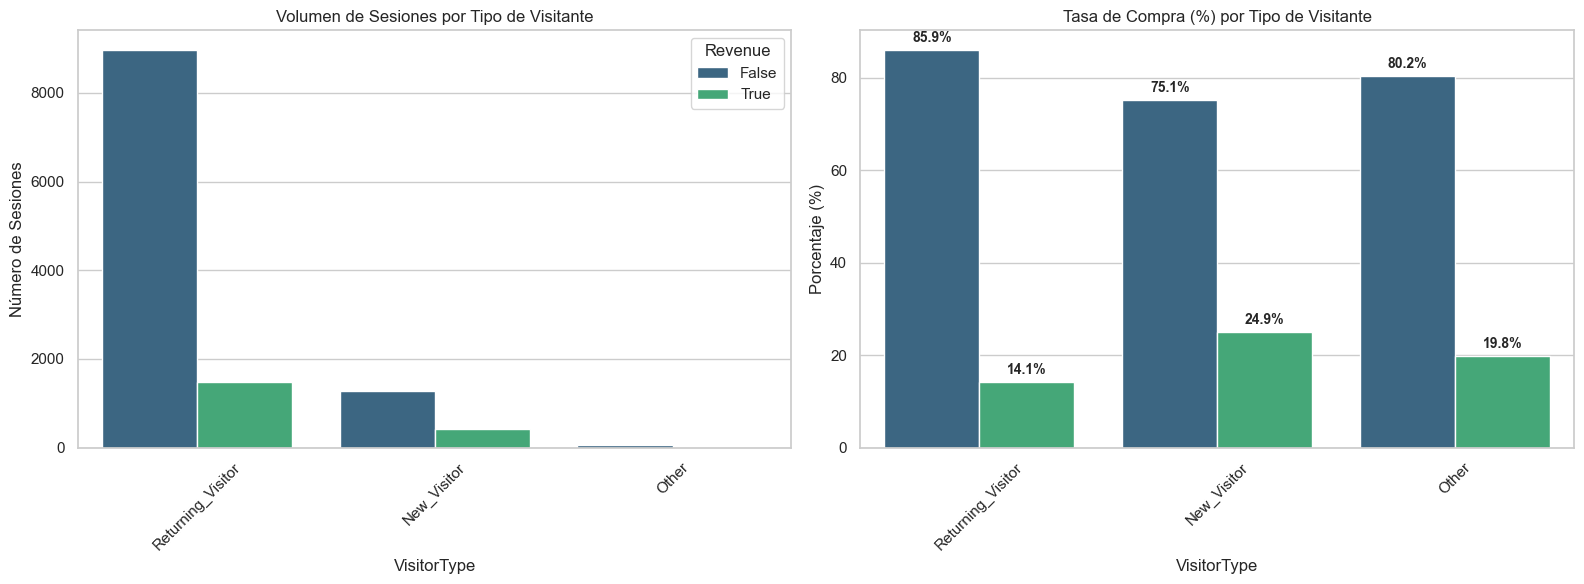

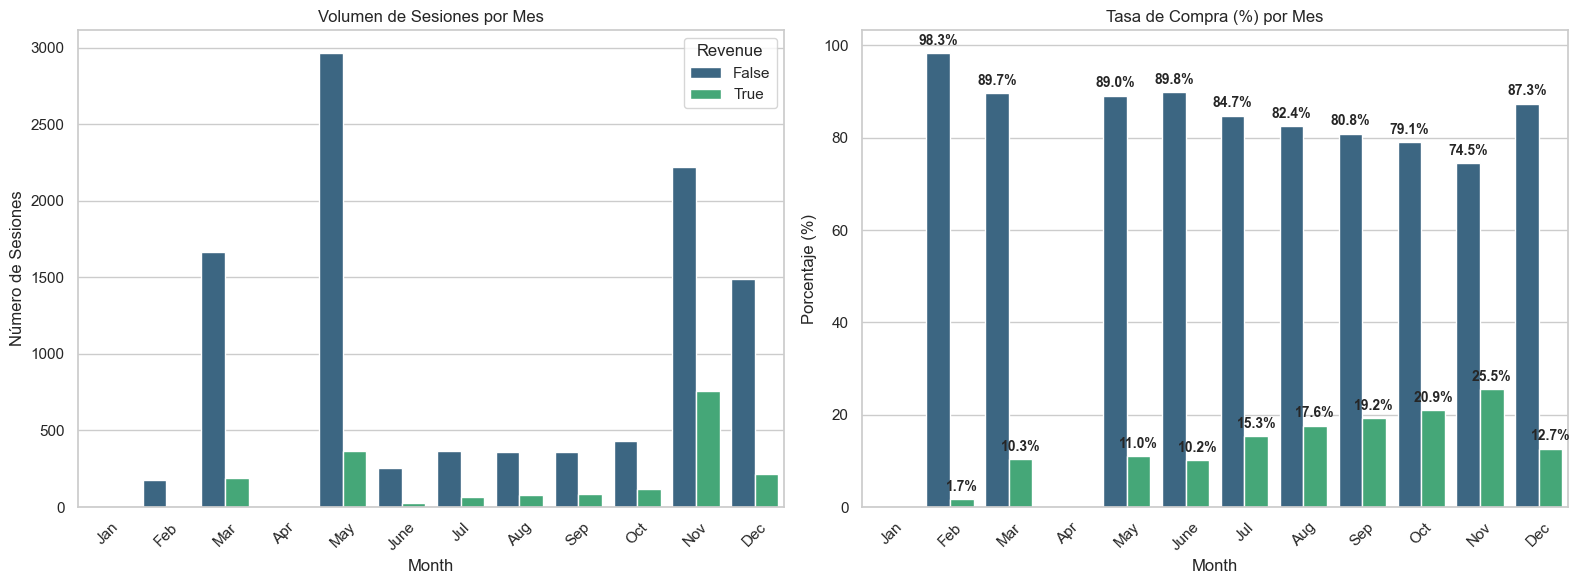

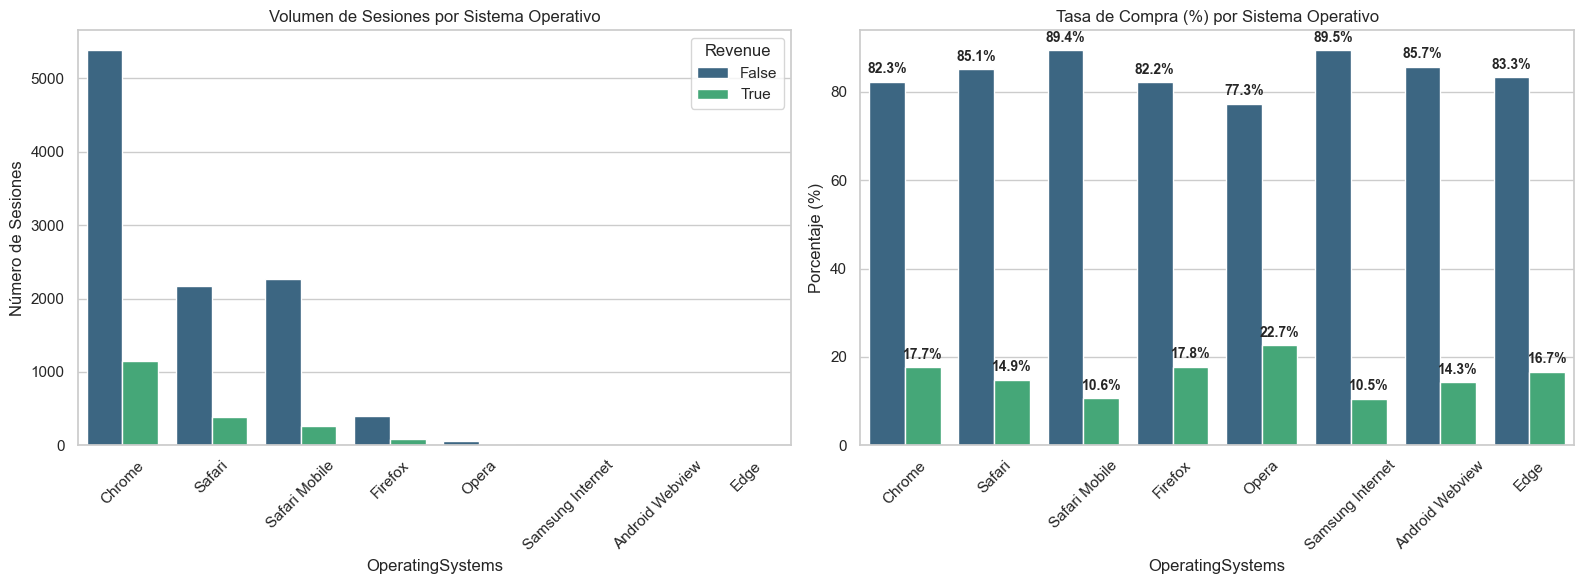

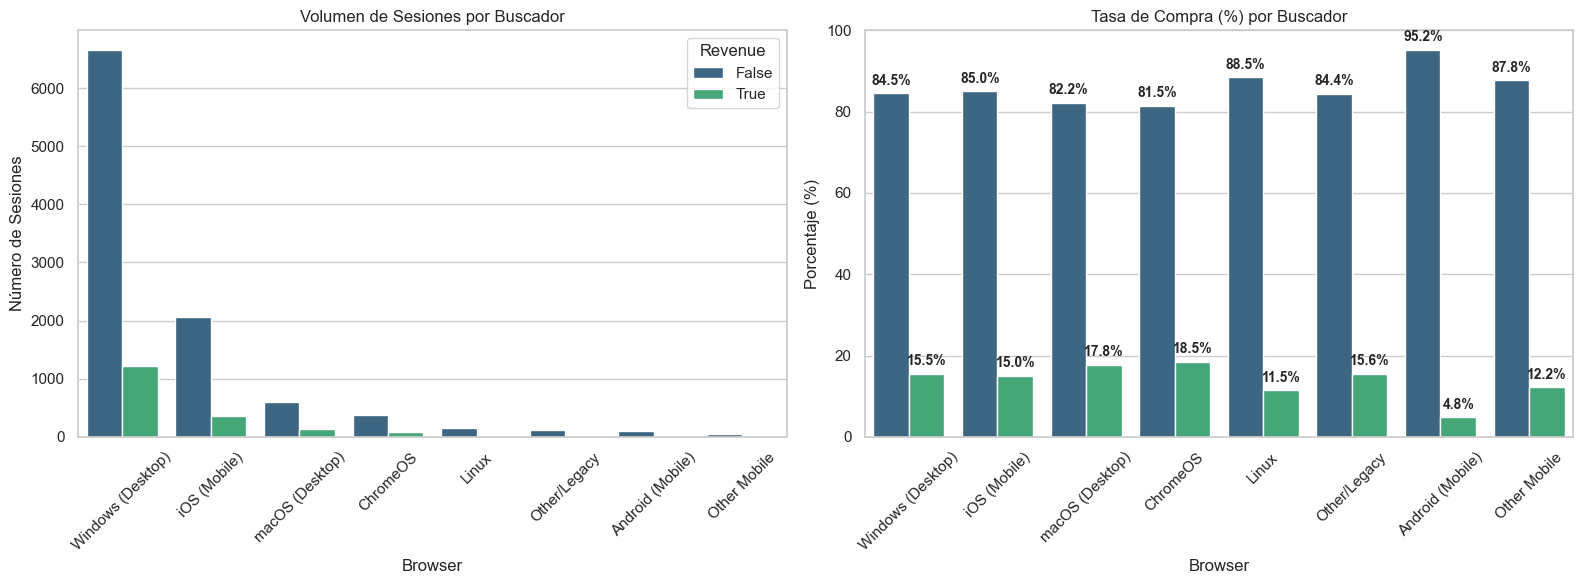

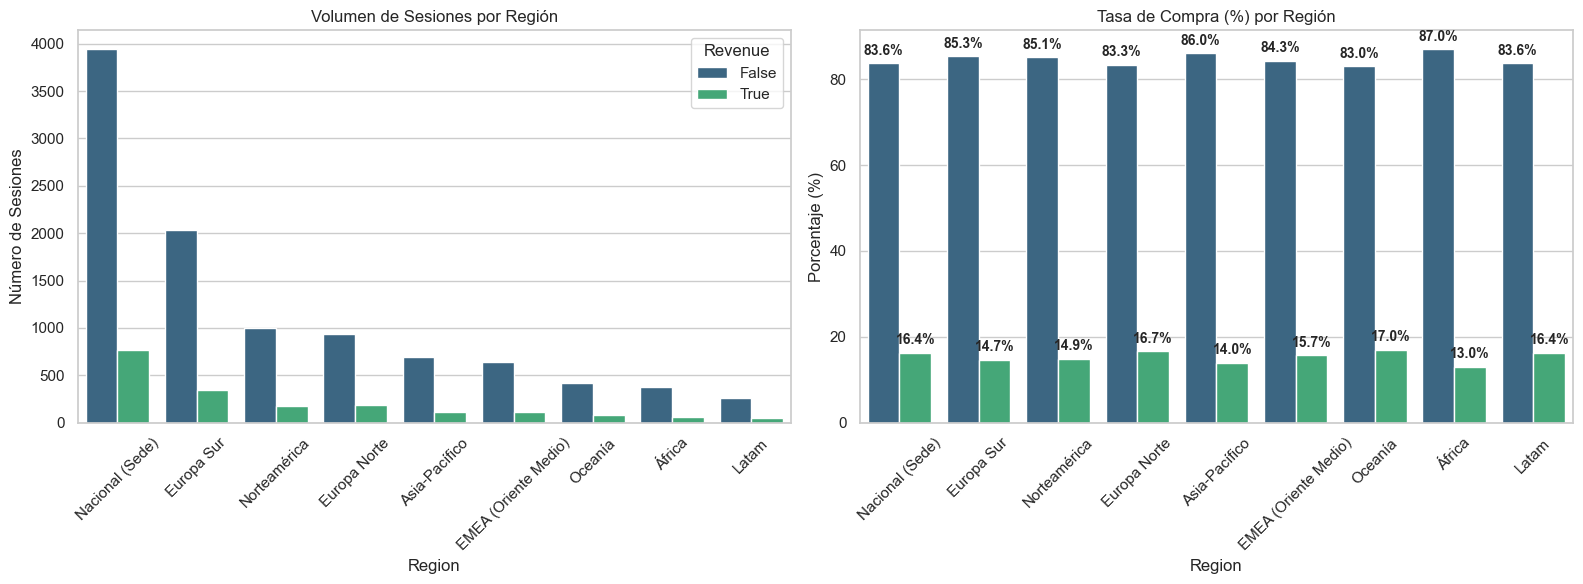

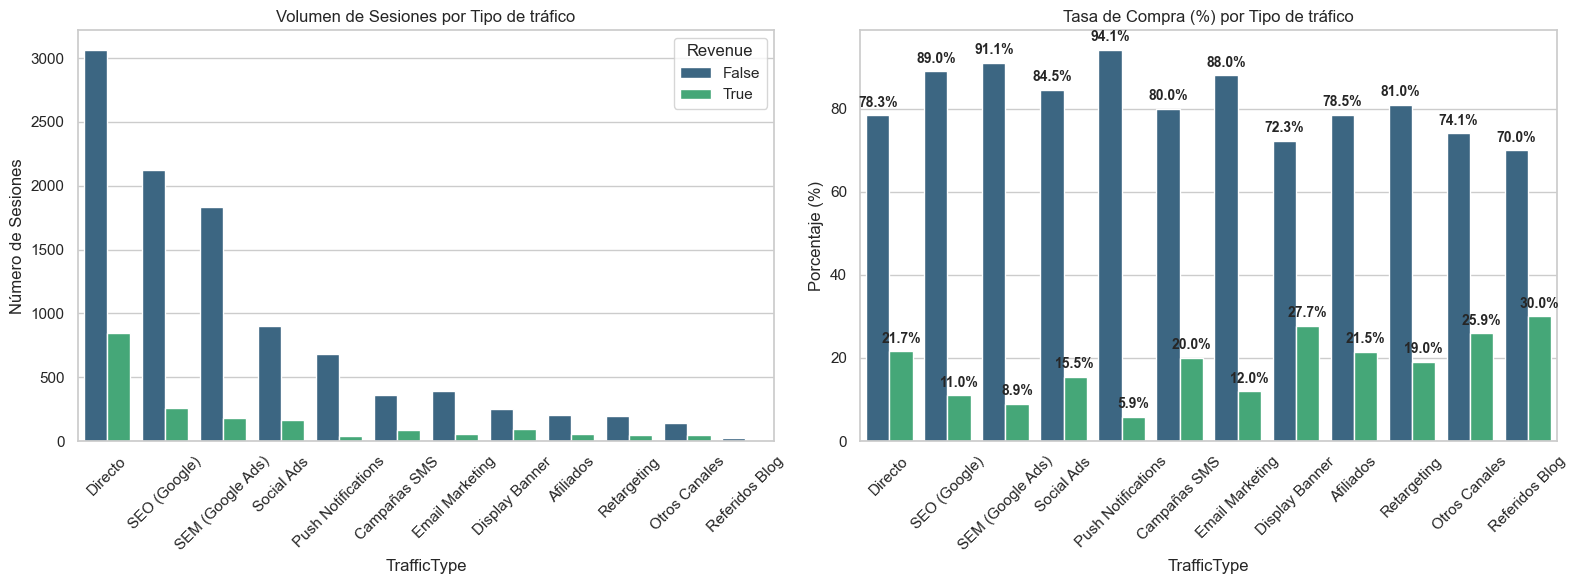

In [34]:
plot_categorical_analysis(df_eda, 'VisitorType', 'Tipo de Visitante', ['Returning_Visitor', 'New_Visitor', 'Other'])
plot_categorical_analysis(df_eda, 'Month', 'Mes', ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plot_categorical_analysis(df_eda, 'OperatingSystems', 'Sistema Operativo')
plot_categorical_analysis(df_eda, 'Browser', 'Buscador')
plot_categorical_analysis(df_eda, 'Region', 'Región')
plot_categorical_analysis(df_eda, 'TrafficType', 'Tipo de tráfico')

## Relaciones entre Variables

### Matriz de Correlación

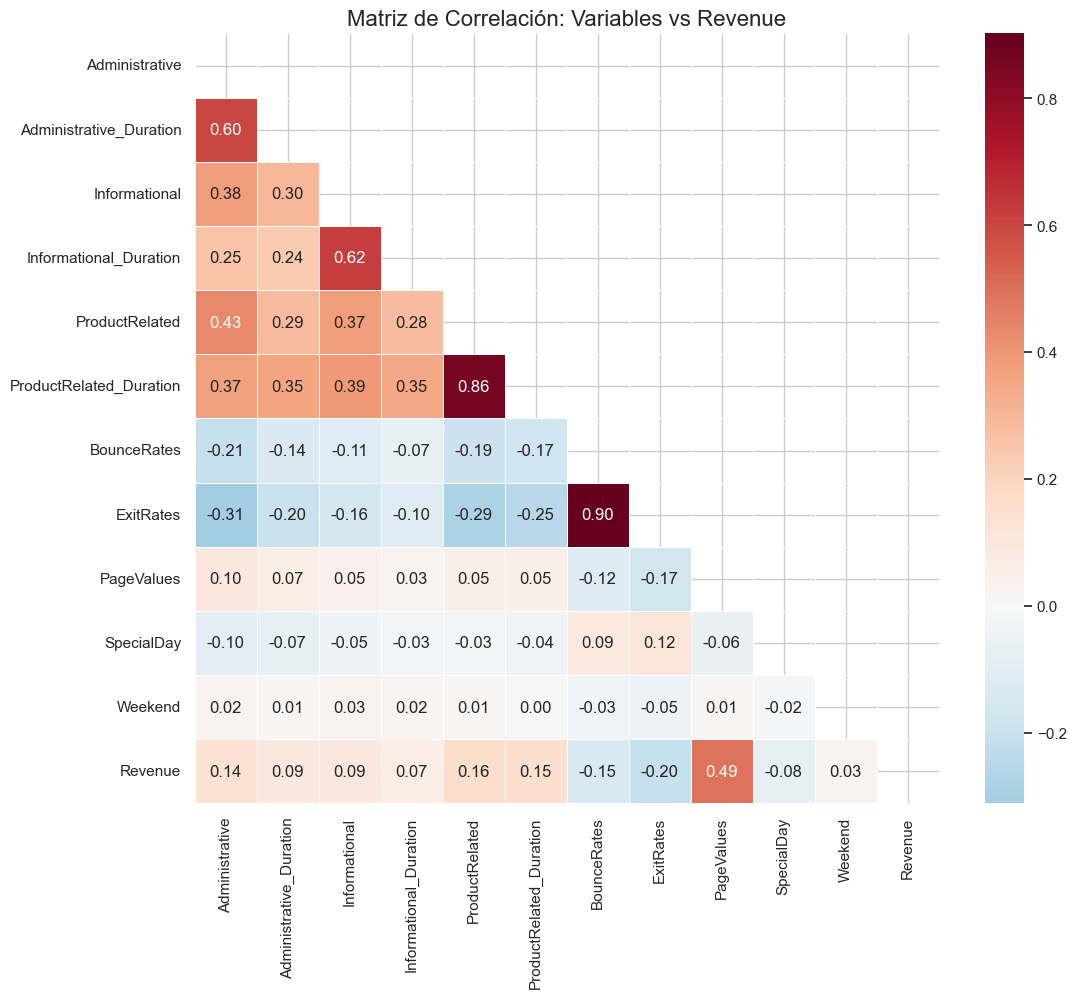

In [20]:
# Matriz de correlación entre las variables numéricas y la variable objetivo (Revenue)

df_corr = df_eda.copy()
df_corr['Revenue'] = df_corr['Revenue'].astype(int)
df_corr['Weekend'] = df_corr['Weekend'].astype(int)

corr_matrix = df_corr.corr(numeric_only=True)

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, 
            mask=mask, 
            annot=True, 
            fmt=".2f", 
            cmap='RdBu_r', 
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlación: Variables vs Revenue', fontsize=16)
plt.show()

### Impacto de `PageValues` en las Compras

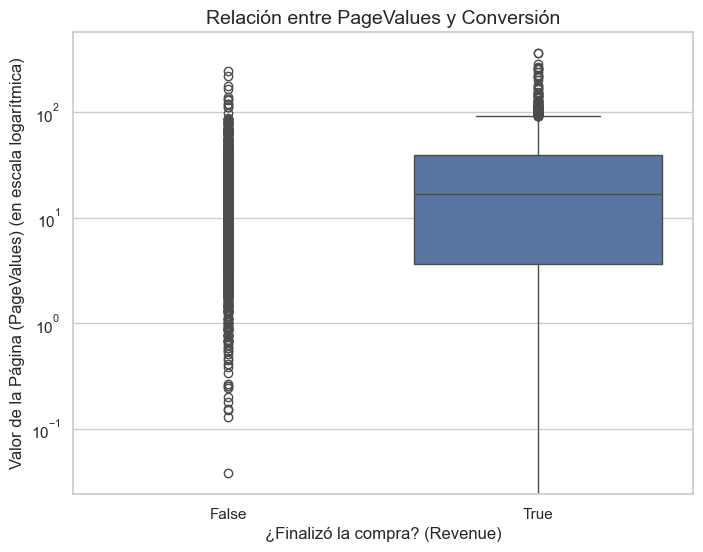

In [21]:
# Gráfica de relación entre PageValues y Compras

plt.figure(figsize=(8, 6))
sns.boxplot(x='Revenue', y='PageValues', data=df_eda)
plt.title('Relación entre PageValues y Conversión', fontsize=14)
plt.xlabel('¿Finalizó la compra? (Revenue)', fontsize=12)
plt.ylabel('Valor de la Página (PageValues) (en escala logarítmica)', fontsize=12)
plt.yscale('log')
plt.show()

In [22]:
print(df_eda.groupby('Revenue')['PageValues'].mean())

Revenue
False     1.999985
True     27.264518
Name: PageValues, dtype: float64


### Impacto de la cercanía a Evento Espacial en las Compras

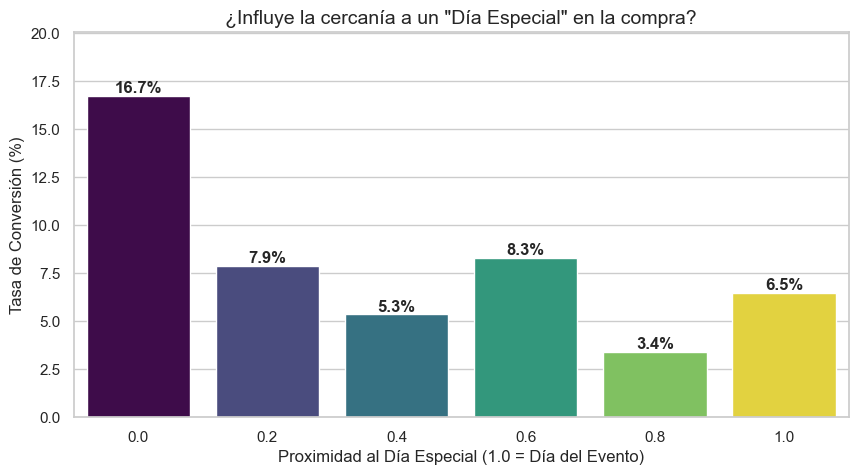

In [23]:
# Gráfica de la tasa de compra en base al ratio de dia especial

special_day_conv = df_eda.groupby('SpecialDay')['Revenue'].mean() * 100
special_day_conv = special_day_conv.reset_index()

plt.figure(figsize=(10, 5))
ax = sns.barplot(data=special_day_conv, x='SpecialDay', y='Revenue', hue='SpecialDay', palette='viridis', legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontweight='bold')

plt.title('¿Influye la cercanía a un "Día Especial" en la compra?', fontsize=14)
plt.ylabel('Tasa de Conversión (%)')
plt.xlabel('Proximidad al Día Especial (1.0 = Día del Evento)')
plt.ylim(0, max(special_day_conv['Revenue']) * 1.2)
plt.show()

## Relaciones Multivariantes de Interés

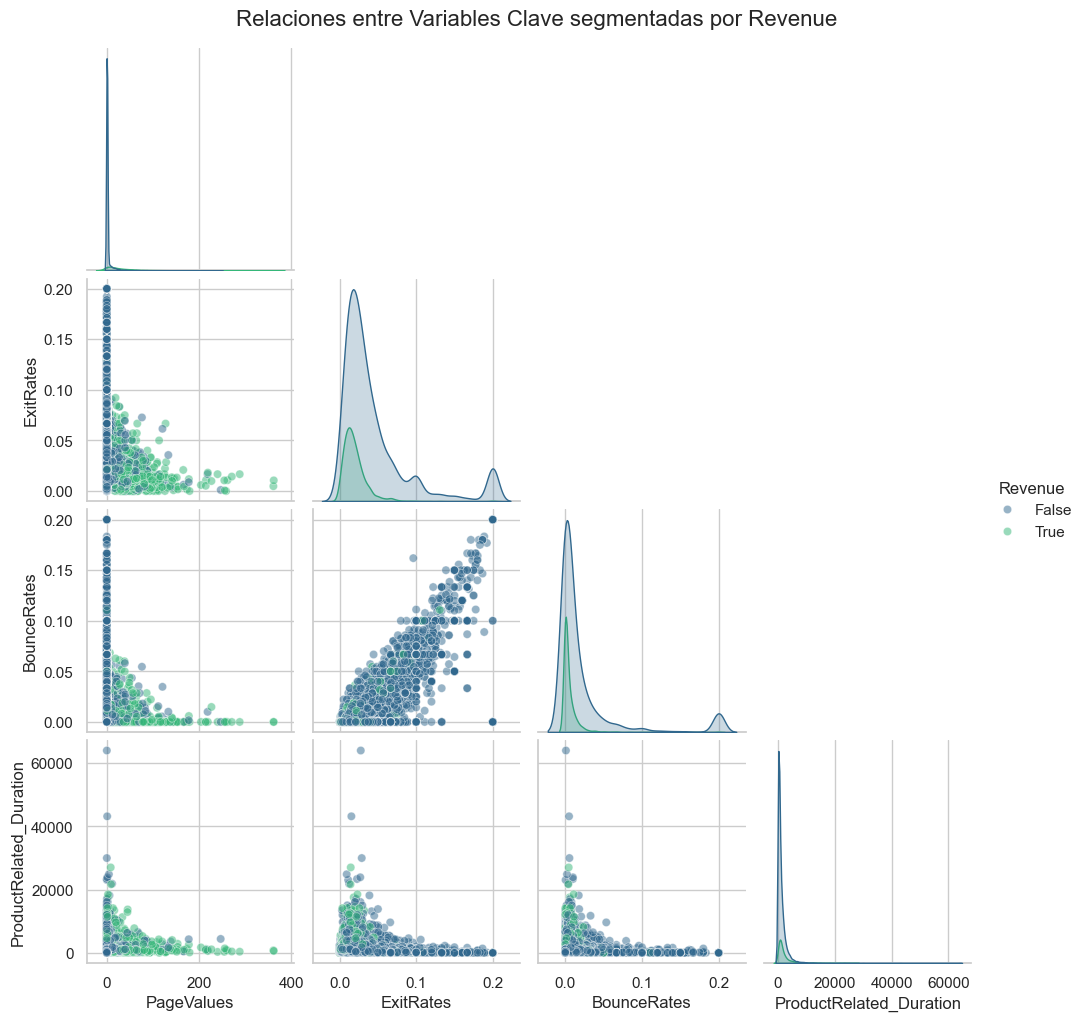

In [24]:
vars_clave = ['PageValues', 'ExitRates', 'BounceRates', 'ProductRelated_Duration', 'Revenue']

sns.pairplot(df_eda[vars_clave], 
             hue='Revenue', 
             palette='viridis', 
             diag_kind='kde', 
             plot_kws={'alpha': 0.5},
             corner=True)

plt.suptitle('Relaciones entre Variables Clave segmentadas por Revenue', y=1.02, fontsize=16)
plt.show()

<Figure size 1000x600 with 0 Axes>

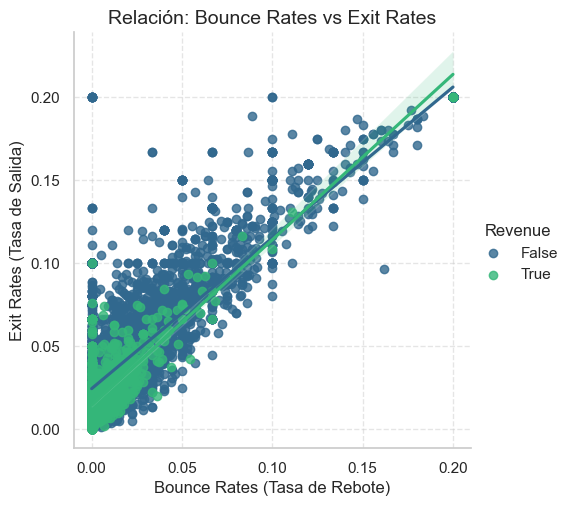

In [25]:
plt.figure(figsize=(10, 6))
sns.lmplot(data=df_eda, 
                x='BounceRates', 
                y='ExitRates', 
                hue='Revenue', 
                palette='viridis')

plt.title('Relación: Bounce Rates vs Exit Rates', fontsize=14)
plt.xlabel('Bounce Rates (Tasa de Rebote)')
plt.ylabel('Exit Rates (Tasa de Salida)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Visualización de los datos en 2D

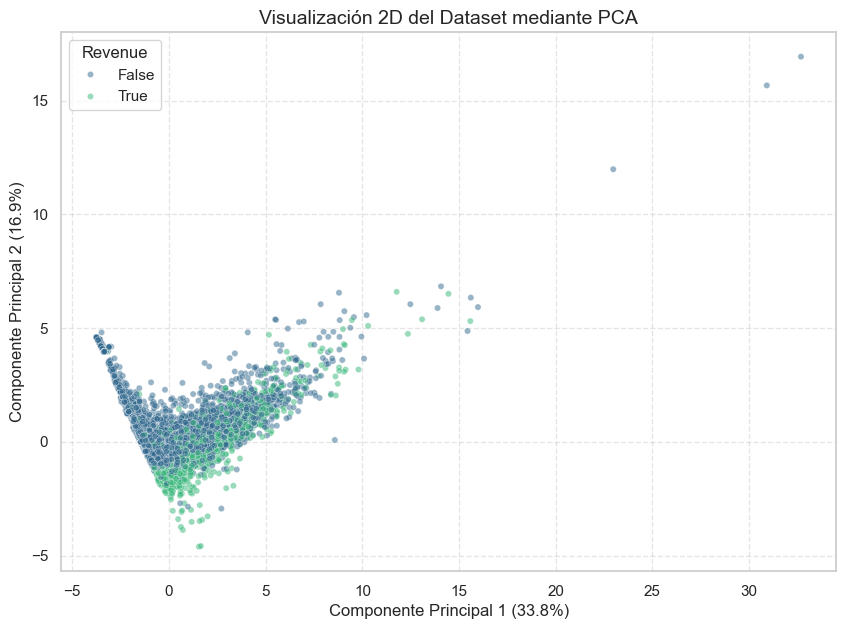

In [26]:

df_numeric = df_eda.select_dtypes(include=[np.number]).drop(columns=['Revenue'], errors='ignore')

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_numeric)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)

df_pca = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
df_pca['Revenue'] = df_eda['Revenue'].values


plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Revenue', data=df_pca, 
                palette='viridis', alpha=0.5, s=20)

plt.title('Visualización 2D del Dataset mediante PCA', fontsize=14)
plt.xlabel(f'Componente Principal 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Componente Principal 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Conclusiones
- El conjunto de datos refleja la realidad del E-Commerce, donde la clase positiva (`Revenue=True`) es un evento minoritario (aprox 15.5%). 
- Aunque los usuarios recurrentes generan el mayor volumen del tráfico, los nuevos visitantes presentan una tasa de compra superior. Esto sugiere que el interés inicial es un motor de compra más fuerte que la navegación recurrente sin compras previas.
- El mes con mas volumen de ventas es Noviembre, lo que sugiere que se trata por el impacto directo de eventos comerciales como Black Friday.
- Se identifica a `PageValues` como la característica con mayor poder predictivo, en la cual se observa una clara separación de densidades entre clases.
- Se observa una correlación lineal positiva entre `ExitRates` y `BounceRates`, lo cual es totalmente lógico en el contexto de navegación web. Por otro lado, los usuarios que realizan una compra mantienen niveles de estas dos variables muy bajos y acotados, funcionando como un filtro negativo.
- Gracias a la visualización en 2D haciendo uso de la técnica de análisis de componentes principales (PCA) se aprecia que las dos clases se encuentran en una única nube de puntos, lo cual confirma que el problema no es linealmente separable.

## Modelado

Tras el EDA realizado sobre el conjunto de datos, para la siguiente fase de modelado del sistema de predicción de potenciales compradores se deberá de tener en cuenta los siguientes aspectos:
